<h1>Implementing an LSTM network using TensorFlow</h1>

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import image

<h3>Model Structure</h3>

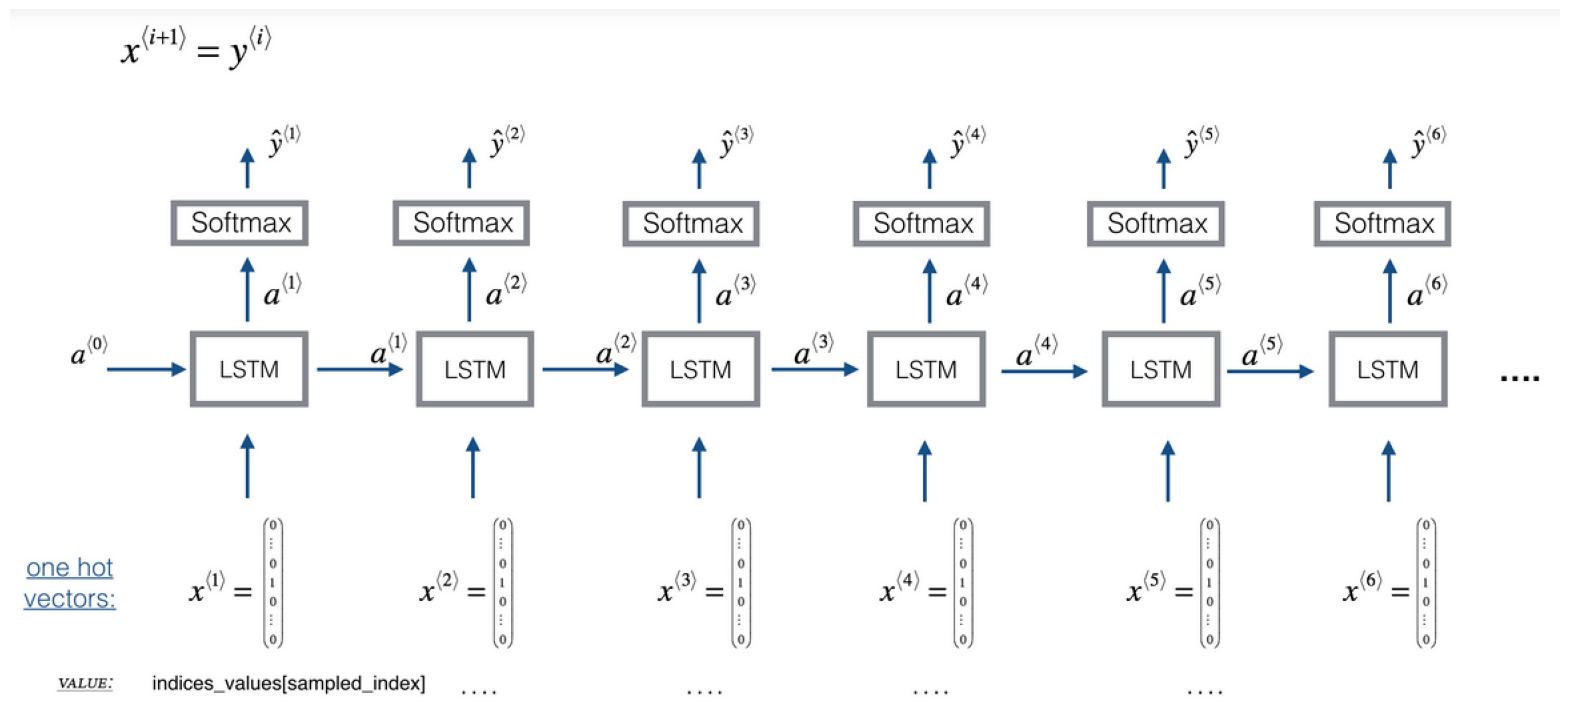

In [7]:
plt.figure(figsize=(20, 12))
path = "lstm-tensor.png"
img = image.imread(path)
plt.imshow(img)
plt.axis("off")
plt.show()

<h3>Building the Model</h3>
<h5>The model takes input X of shape (𝑚,𝑇𝑥,90) and labels Y of shape (𝑇𝑦,𝑚,90). </h5>

In [8]:
n_a = 64  # number of dimensions for the hidden state of each LSTM cell
n_values = 90  # number of music values

In [1]:
class LSTM:
    
    def __init__(self, epochs, num_hidden_units, learning_rate, weight_decay):


        self.epochs = epochs
        self.num_hidden_units = num_hidden_units
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.params = None
        self.cost_ = None




    def initialize_params(self, n_a, n_x, n_y, m):

   

        initializer = tf.keras.initializers.GlorotNormal(seed=0)

        
        a0 = tf.Variable(tf.zeros(shape=(n_a, m), dtype=tf.float32), trainable=False)
        c0 = tf.Variable(tf.zeros(shape=(n_a, m), dtype=tf.float32), trainable=False)

       
        Wf = initializer(shape=(n_a, n_a + n_x))  
        Wu = initializer(shape=(n_a, n_a + n_x))  
        Wc = initializer(shape=(n_a, n_a + n_x))  
        Wo = initializer(shape=(n_a, n_a + n_x))  

        bf = tf.ones((n_a, 1), dtype=tf.float32)  
        bu = tf.zeros((n_a, 1), dtype=tf.float32)  
        bc = tf.zeros((n_a, 1), dtype=tf.float32)  
        bo = tf.zeros((n_a, 1), dtype=tf.float32)

        Wy = initializer(shape=(n_y, n_a)) 
        by = tf.zeros((n_y, 1), dtype=tf.float32) 

        params = {
            "Wf": Wf, "bf": bf,
            "Wu": Wu, "bu": bu,
            "Wc": Wc, "bc": bc,
            "Wo": Wo, "bo": bo,
            "Wy": Wy, "by": by
        }

        return params, a0, c0




    def compute_cost(self, y_true, y_hat, t_x):
    

        loss_fn = tf.keras.losses.CategoricalCrossentropy()

        loss = loss_fn(y_true, y_hat)

        return loss




    def cell_forward(self, x, c_prev, a_prev, params):
   

        forget_gate = tf.keras.activations.sigmoid(tf.linalg.matmul(params["Wf"], tf.concat(values=[a_prev, x], axis=0)) + params["bf"])
        update_gate = tf.keras.activations.sigmoid(tf.linalg.matmul(params["Wu"], tf.concat(values=[a_prev, x], axis=0)) + params["bu"])
        cell_state = tf.math.tanh(tf.linalg.matmul(params["Wc"], tf.concat(values=[a_prev, x], axis=0)) + params["bc"])
        c_next = forget_gate * c_prev + update_gate * cell_state
        output_gate = tf.keras.activations.sigmoid(tf.linalg.matmul(params["Wo"], tf.concat(values=[a_prev, x], axis=0)) + params["bo"])
        a_next = output_gate * tf.math.tanh(c_next)
        y_pred = tf.keras.activations.softmax(tf.linalg.matmul(params["Wy"], a_next) + params["by"])

        cache = (a_next, c_next, a_prev, c_prev, forget_gate, update_gate, cell_state, output_gate, x, params)

        return a_next, c_next, y_pred, cache



    def cells_forward(self, x, a0, params):
     

        caches = []
        n_x, m, t_x = x.shape
        n_y, n_a = params["Wy"].shape

        a = tf.TensorArray(dtype=tf.float32, size=t_x, clear_after_read=False)
        c = tf.TensorArray(dtype=tf.float32, size=t_x, clear_after_read=False)
        y = tf.TensorArray(dtype=tf.float32, size=t_x, clear_after_read=False)

        a_next = a0
        c_next = tf.zeros(shape=(n_a, m), dtype=tf.float32)

        for t in range(t_x):

            xt = x[:, :, t]
            a_next, c_next, yt, cache = self.cell_forward(
                x=xt,
                c_prev=c_next,
                a_prev=a_next,
                params=params
            )
            a = a.write(t, a_next)
            c = c.write(t, c_next)
            y = y.write(t, yt)

            caches.append(cache)

        a = tf.transpose(a.stack(), perm=[1, 2, 0])
        c = tf.transpose(c.stack(), perm=[1, 2, 0])
        y = tf.transpose(y.stack(), perm=[1, 2, 0])
        caches = (caches, x)

        return a, c, y, caches


    def lstm_model(self, x, y):
      
        y = tf.convert_to_tensor(y)

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=self.learning_rate,
            weight_decay=self.weight_decay
        )

        n_x, m, t_x = x.shape
        _, n_y = y.shape
        n_a = self.num_hidden_units

        params, a0, c0 = self.initialize_params(
            n_a=n_a,
            n_x=n_x,
            n_y=n_y,
            m=m
        )

        for i in range(self.epochs):

            with tf.GradientTape() as tape:

                a0.assign(tf.zeros_like(a0))
                c0.assign(tf.zeros_like(c0))

                a, c, y_hat, cache = self.cells_forward(
                    x=x,
                    a0=a0,
                    params=params
                )

                cost = self.compute_cost(
                    y_true=y,
                    y_hat=y_hat,
                    t_x=t_x
                )
                self.cost_.append(cost)

            print(f"Epoch {i + 1}/{self.epochs}, Cost: {cost}")

            variables = list(params.values())
            gradients = tape.gradient(cost, variables)
            optimizer.apply_gradients(zip(gradients, variables))

        self.params = params

        return self.params, self.cost_